## Advanced Machine Learning – Project 1  
### Logistic Regression with FISTA

This notebook presents the implementation and experimental analysis of logistic regression using FISTA aptimization algorithm.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import time

from src.utils import *
from src.fista_logreg import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

### 1. Data Loading

In this section we load and inspect the datasets used in the experiments.

In [3]:
processed_datasets = {}

datasets = ["biodeg", "htru2", "magic", "spambase"]

for name in datasets:

    X, y = load_dataset(name)
    X, removed = prepare_dataset(X, threshold=0.9)
    y = y.loc[X.index]
    dataset_summary(X, y, name)
    if removed:
        print(f"Removed features due to high correlation: {removed}\n")

    processed_datasets[name] = {
        "X": X,
        "y": y,
    }

----------------------------------------
Dataset: biodeg
----------------------------------------
Number of samples: 1055
Number of features: 38

Target distribution:
Class
1    699
0    356
Name: count, dtype: int64


Removed features due to high correlation: ['V15', 'V27', 'V39']

----------------------------------------
Dataset: htru2
----------------------------------------
Number of samples: 17898
Number of features: 6

Target distribution:
class
0    16259
1     1639
Name: count, dtype: int64


Removed features due to high correlation: ['Profile_kurtosis', 'DM_kurtosis']

----------------------------------------
Dataset: magic
----------------------------------------
Number of samples: 19020
Number of features: 9

Target distribution:
class
1    12332
0     6688
Name: count, dtype: int64


Removed features due to high correlation: ['fConc1']

----------------------------------------
Dataset: spambase
----------------------------------------
Number of samples: 4601
Number of featu

During data loading, we perform early preprocessing:
- remove highly correlated features (correlation > 0.9)
- remove rows with missing values (impact small number of rows so it has no impact on the experiments)

### 2. Logistic Regression with FISTA

In this section we compare our implementation of Logistic Lasso regression using the Fast Iterative Shrinkage-Thresholding Algorithm (FISTA) with sklearn implementation.

**Experiment 1 description**

In order to compare our implementation with the scikit-learn implementation we conduct an experiment - results of which are presented below.

For different values of max_iter, we train models using our FISTA-based implementation with a fixed regularization parameter λ = 1. For the sklearn baseline, we use an equivalent setting with C = 1/𝜆.

For the sklearn model, we use the following configuration:
LogisticRegression(l1_ratio=1, C=1/lam, solver='liblinear', fit_intercept=False, tol=1e-6, max_iter=max_iter, random_state=42).

Before training, all datasets are scaled using MinMax normalization and split into training and validation subsets.

For each configuration, we compute the ROC AUC score on the validation set and record the computation time, allowing us to compare both predictive performance and efficiency across methods.

In [11]:
def _print_progress(message):
    sys.stdout.write('\r' + message)
    sys.stdout.flush()


def compare_fista_sklearn(processed_datasets, max_iters=[100, 500, 1000], lam=1.0, fit_intercept=False):
    """
    Compare FISTALogisticLasso with sklearn LogisticRegression (L1).

    Parameters
    ----------
    processed_datasets (dict): Dictionary of datasets with structure {name: {"X": X, "y": y}}
    max_iters (list of int): List of max_iter values to test for FISTA.
    lam (float): Regularization parameter for FISTA and sklearn (C = 1/lam).
    fit_intercept (bool): Weather to fit intercept.
    """
    results = []

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))

    for idx, (name, data) in enumerate(processed_datasets.items()):
        
        ax = axes.flatten()[idx]

        X, y = data["X"], data["y"]
        X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_valid = scaler.transform(X_valid)

        # --- FISTA ---
        fista_scores = []
        fista_times = []
        for max_iter in max_iters:
            _print_progress(f"             | dataset: {name} | FISTA                 ")
            _print_progress(f"max_iter={max_iter} ")
            model = FISTALogisticLasso(lam=lam, max_iter=max_iter, tol=1e-6, fit_intercept=fit_intercept)

            start = time.perf_counter()
            model.fit(X_train, y_train, auto_validate=False)
            end = time.perf_counter()
            elapsed = end - start

            y_proba = model.predict_proba(X_valid)
            score = roc_auc_score(y_valid, y_proba)
            
            fista_scores.append(score)
            fista_times.append(elapsed)

            results.append({
                "dataset": name,
                "method": "FISTA",
                "max_iter": max_iter,
                "AUC_ROC_score": score,
                "time": elapsed
            })

        # --- sklearn ---
        sklearn_scores = []
        sklearn_times = []
        for max_iter in max_iters:
            _print_progress(f"             | dataset: {name} | sklearn L1            ")
            _print_progress(f"max_iter={max_iter} ")
            clf = LogisticRegression(l1_ratio=1, C=1/lam, solver='liblinear', fit_intercept=fit_intercept, tol=1e-6, max_iter=max_iter, random_state=42)

            start = time.perf_counter()
            clf.fit(X_train, y_train)
            end = time.perf_counter()
            elapsed = end - start

            y_proba = clf.predict_proba(X_valid)[:, 1]
            score = roc_auc_score(y_valid, y_proba)
            
            sklearn_scores.append(score)
            sklearn_times.append(elapsed)

            results.append({
                "dataset": name,
                "method": "sklearn L1",
                "max_iter": max_iter,
                "AUC_ROC_score": score,
                "time": elapsed
            })

        # --- plot ---
        ax_score = axes[0, idx]
        ax_time = axes[1, idx]

        all_scores = fista_scores + sklearn_scores
        center = (min(all_scores) + max(all_scores)) / 2

        ax_score.plot(max_iters, fista_scores, marker='o', label='FISTA', color="#FE6100")
        ax_score.plot(max_iters, sklearn_scores, marker='x', label='sklearn L1', color="#648FFF")
        ax_score.set_title(f"Dataset: {name}")
        ax_score.set_xlabel("max_iter")
        ax_score.set_ylabel("ROC-AUC")
        ax_score.set_ylim(center - 0.05, center + 0.05) 
        ax_score.grid(alpha=0.3)

        ax_time.plot(max_iters, fista_times, marker='o', label='FISTA', color="#FE6100", linestyle="dashed")
        ax_time.plot(max_iters, sklearn_times, marker='x', label='sklearn L1', color="#648FFF", linestyle="dashed")

        ax_time.set_ylabel("Time (s)")
        ax_time.set_yscale('log')
        ax_time.set_xlabel("max_iter")
        ax_time.grid(alpha=0.3)
        
    sys.stdout.write('\r' + ' ' * 100 + '\r')
    sys.stdout.flush()

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
    handles,
        labels,
        loc='lower center',
        ncol=3,
        bbox_to_anchor=(0.5, -0.02),
        frameon=False
    )

    plt.suptitle("Comparison of Custom FISTA Implementation with Scikit-learn", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.99])
    plt.show()

**𝜆 = 1**

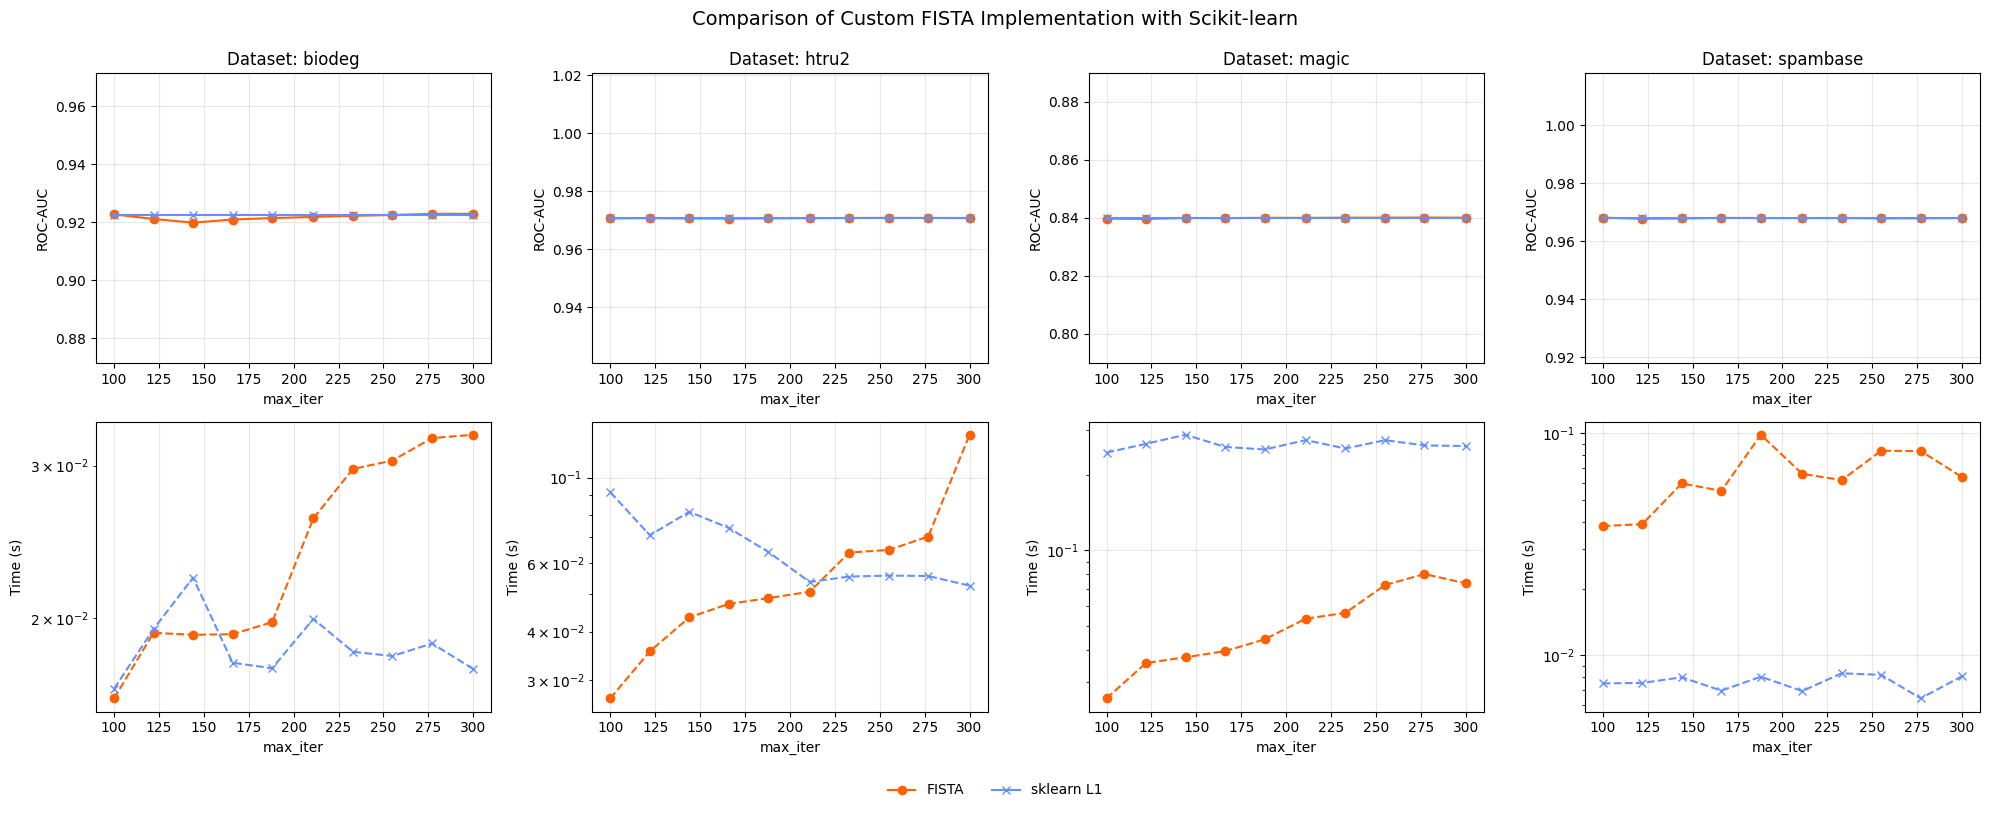

In [14]:
compare_fista_sklearn(processed_datasets, max_iters=np.linspace(100, 300, 10).astype(int), lam=1.0)

**𝜆 = 0.1**

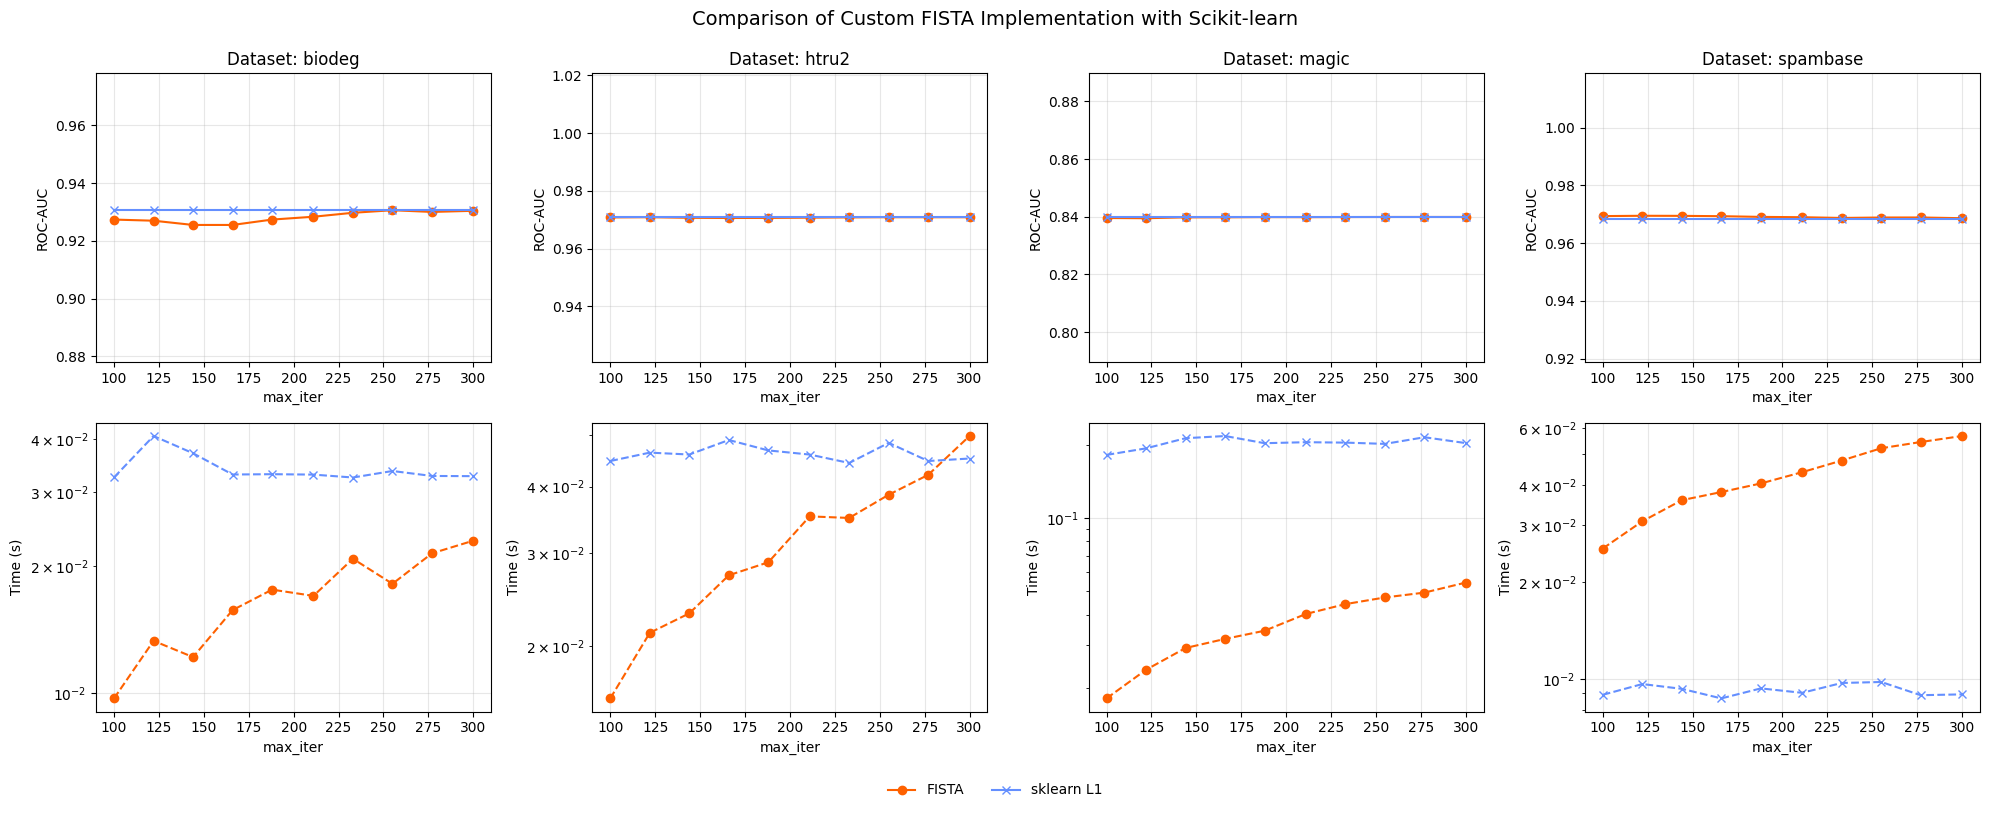

In [8]:
compare_fista_sklearn(processed_datasets, max_iters=np.linspace(100, 300, 10).astype(int), lam=0.1)

**fit_intercept=True**

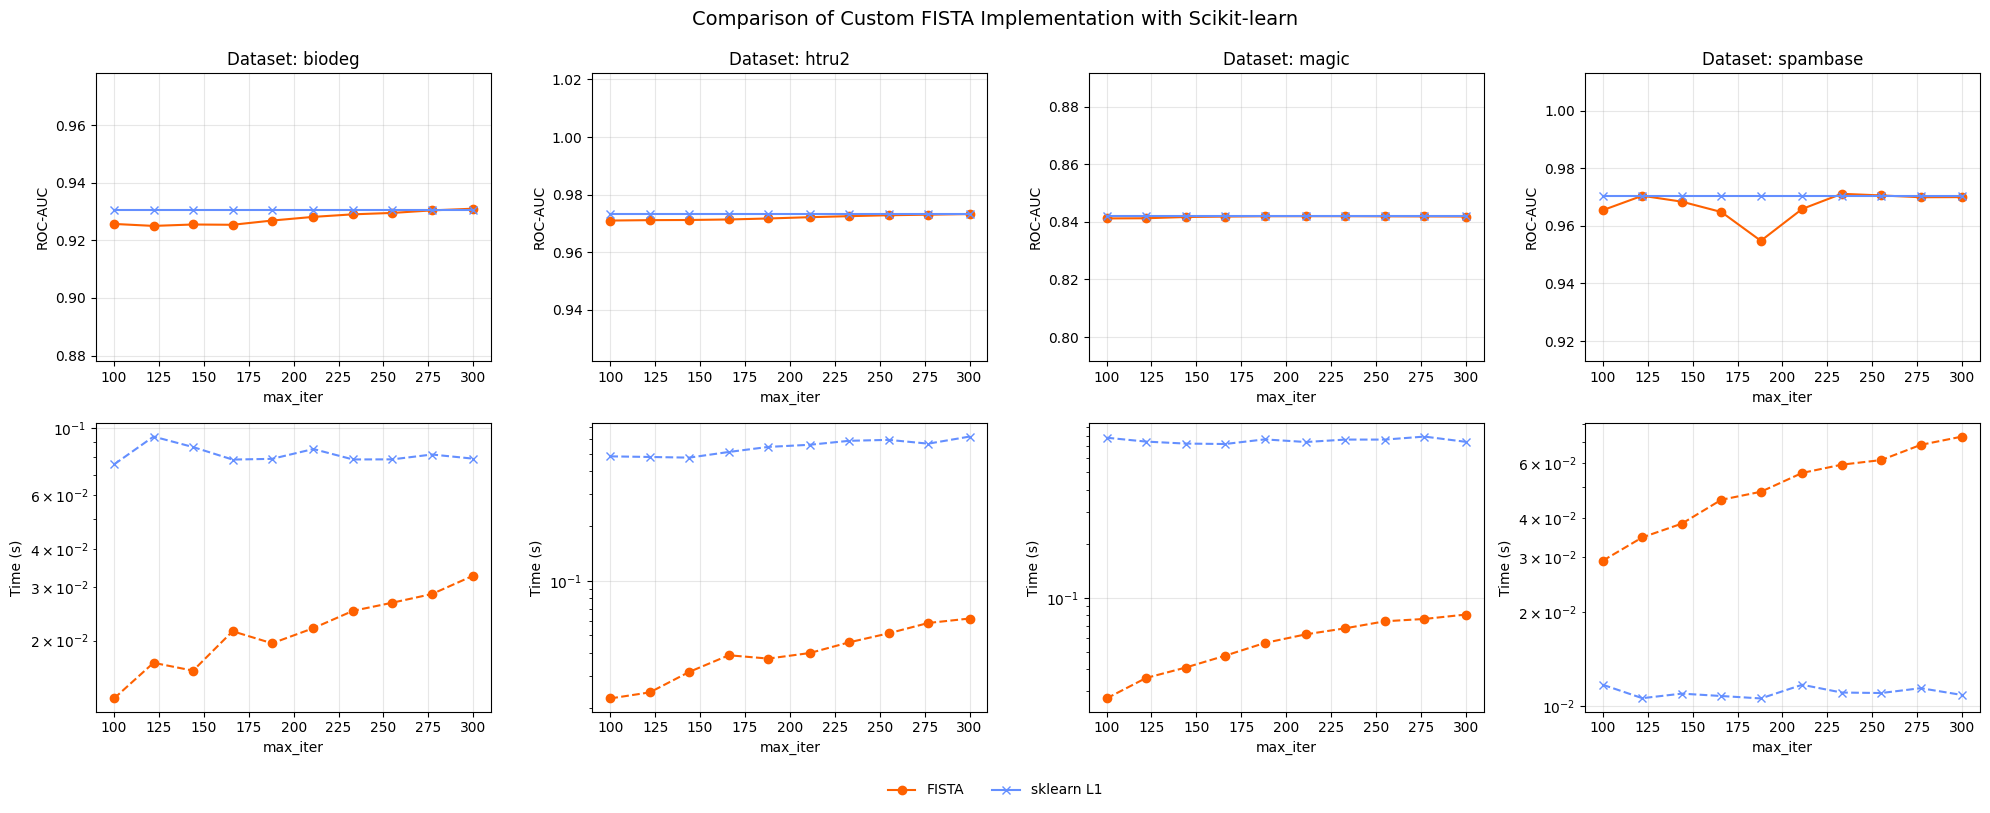

In [16]:
compare_fista_sklearn(processed_datasets, max_iters=np.linspace(100, 300, 10).astype(int), lam=0.1, fit_intercept=True)

**Experiment 2 Description**

In this experiment, we analyze how different evaluation metrics influence the selection of the optimal regularization parameter λ in our FISTA-based Logistic Lasso model.

For each dataset, we train the model over a range of λ values (logarithmically spaced) and enable automatic validation. During training, the model evaluates performance on a validation set using a specified metric and selects the best λ accordingly.

All datasets are first scaled using MinMax normalization and split into training and validation subsets.

For each metric, we record the validation score across λ values and identify the optimal λ that maximizes the given metric. This allows us to study how the choice of evaluation criterion affects optimal λ.

In [20]:
def compare_fista_validation(
    processed_datasets,
    measures=("f1", "precision", "recall", "roc_auc", "pr_auc", "balanced_accuracy"),
    lambda_values=np.logspace(-5, 1, 30),
    max_iter=500
):
    """
    Analyze the effect of different validation metrics on lambda selection
    in FISTALogisticLasso.

    Parameters
    ----------
    processed_datasets : dict
        Dictionary of datasets with structure {name: {"X": X, "y": y}}.
    measures : tuple of str
        Evaluation metrics used for validation-based lambda selection.
        Supported metrics include: "f1", "precision", "recall",
        "roc_auc", "pr_auc", and "balanced_accuracy".
    lambda_values : array-like
        Sequence of lambda values (regularization strengths) to evaluate.
    max_iter : int
        Maximum number of iterations for the FISTA optimizer.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing validation results for each dataset, metric,
        and lambda value, including the selected best lambda.
    """

    results = []

    n_datasets = len(processed_datasets)
    n_measures = len(measures)

    fig, axes = plt.subplots(n_measures, n_datasets, figsize=(4*n_datasets, 3*n_measures))

    if n_measures == 1:
        axes = np.expand_dims(axes, axis=0)
    if n_datasets == 1:
        axes = np.expand_dims(axes, axis=1)

    for col_idx, (name, data) in enumerate(processed_datasets.items()):

        X, y = data["X"], data["y"]

        X_train, X_valid, y_train, y_valid = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_valid = scaler.transform(X_valid)

        for row_idx, measure in enumerate(measures):

            model = FISTALogisticLasso(
                lambda_values=lambda_values,
                max_iter=max_iter
            )

            model.fit(
                X_train,
                y_train,
                auto_validate=True,
                X_valid=X_valid,
                y_valid=y_valid,
                measure=measure
            )

            for lam, score in zip(model.lambda_values, model.scores_):
                results.append({
                    "dataset": name,
                    "measure": measure,
                    "lambda": lam,
                    "score": score,
                    "best_lambda": model.best_lambda_,
                })

            ax = axes[row_idx, col_idx]

            ax.plot(
                model.lambda_values,
                model.scores_,
                linewidth=1
            )

            ax.axvline(
                model.best_lambda_,
                linestyle="--",
                linewidth=2
            )

            ax.set_xscale("log")
            ax.set_title(f"{name}")
            
            if col_idx == 0:
                ax.set_ylabel(measure)

            if row_idx == n_measures - 1:
                ax.set_xlabel("lambda")

            ax.grid(alpha=0.3)


    plt.suptitle("FISTA lambda validation paths", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.grid(alpha=0.3)
    plt.show()

    df = pd.DataFrame(results)
    df.to_csv("results/fista_validation_results.csv", index=False)

    return df

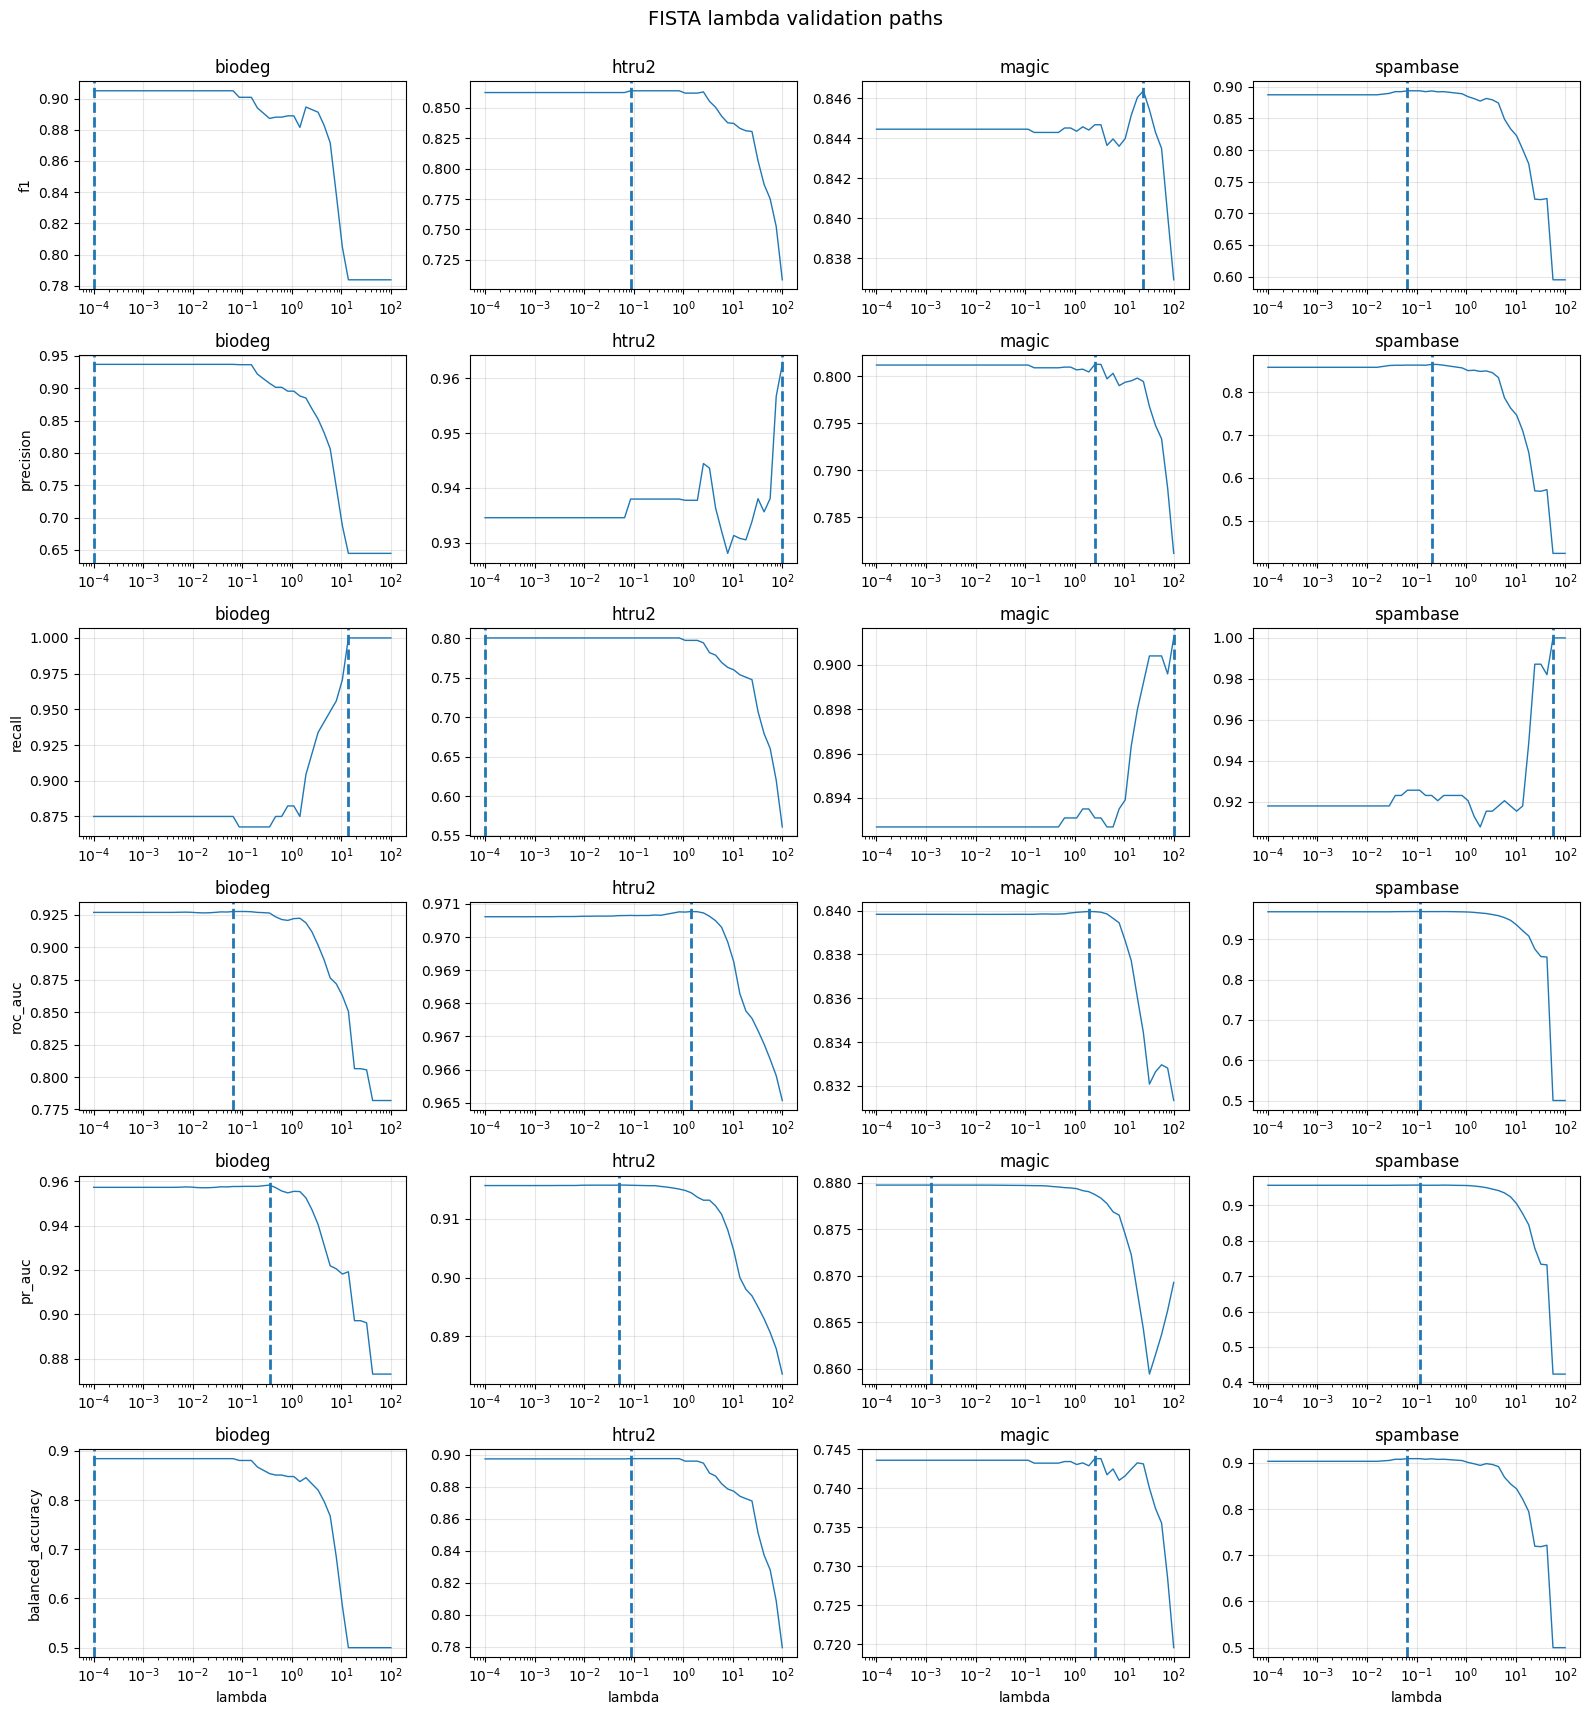

In [21]:
df = compare_fista_validation(
    processed_datasets,
    measures=("f1", "precision", "recall", "roc_auc", "pr_auc", "balanced_accuracy"),
    lambda_values = np.logspace(-4, 2, 50),
    max_iter=200
)

**Experiment 3 Description**

In this experiment, we investigate how the choice of validation metric used for selecting the optimal regularization parameter λ influences the final model performance on unseen test data.

For each dataset, we perform repeated random splits into training, validation, and test subsets. For every split, we train the FISTA-based Logistic Lasso model over a predefined range of λ values. The optimal λ is selected based on a chosen validation metric.

After selecting the best λ for each metric, we evaluate the resulting model on a held-out test set using a fixed evaluation metric (e.g., ROC AUC). This procedure is repeated multiple times to account for variability due to data splitting.

The results are summarized using boxplots, allowing us to compare how different validation strategies impact the distribution of test performance and the stability of λ selection.

In [38]:
def compare_validation_strategies(
    processed_datasets,
    measures=("f1", "precision", "recall", "balanced_accuracy", "roc_auc", "pr_auc"),
    lambda_values=np.logspace(-5, 1, 30),
    n_repeats=10,
    test_metric="roc_auc",
    max_iter=500,
    random_state=42
):

    """
    Evaluate the impact of different validation metrics on lambda selection
    and downstream test performance in FISTALogisticLasso.

    Parameters
    ----------
    processed_datasets : dict
        Dictionary of datasets with structure {name: {"X": X, "y": y}}.
    measures : tuple of str
        Validation metrics used to select the optimal lambda. Supported
        metrics include: "f1", "precision", "recall", "balanced_accuracy",
        "roc_auc", and "pr_auc".
    lambda_values : array-like
        Sequence of lambda values (regularization strengths) to evaluate.
    n_repeats : int
        Number of repeated random train/validation/test splits.
    test_metric : str
        Metric used to evaluate model performance on the test set.
        Supported: "roc_auc", "pr_auc", "f1", "balanced_accuracy".
    max_iter : int
        Maximum number of iterations for the FISTA optimizer.
    random_state : int
        Base random seed used for reproducible data splits.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing test scores, selected lambda values, and
        metadata for each dataset, validation metric, and repeat.
    """
    results = []

    for dataset_name, data in processed_datasets.items():

        X, y = data["X"], data["y"]

        for repeat in range(n_repeats):

            X_train, X_temp, y_train, y_temp = train_test_split(
                X, y, test_size=0.4, random_state=random_state + repeat
            )

            X_valid, X_test, y_valid, y_test = train_test_split(
                X_temp, y_temp, test_size=0.5, random_state=random_state + repeat
            )

            scaler = MinMaxScaler()
            X_train = scaler.fit_transform(X_train)
            X_valid = scaler.transform(X_valid)
            X_test = scaler.transform(X_test)

            for measure in measures:

                model = FISTALogisticLasso(
                    lambda_values=lambda_values,
                    max_iter=max_iter
                )

                model.fit(
                    X_train,
                    y_train,
                    auto_validate=True,
                    X_valid=X_valid,
                    y_valid=y_valid,
                    measure=measure
                )

                proba = model.predict_proba(X_test)

                if test_metric == "roc_auc":
                    score = roc_auc_score(y_test, proba)

                elif test_metric == "pr_auc":
                    score = average_precision_score(y_test, proba)

                else:
                    y_pred = (proba >= 0.5).astype(int)

                    if test_metric == "f1":
                        score = f1_score(y_test, y_pred)
                    elif test_metric == "balanced_accuracy":
                        score = balanced_accuracy_score(y_test, y_pred)
                    else:
                        raise ValueError("Unsupported test metric")

                results.append({
                    "dataset": dataset_name,
                    "measure": measure,
                    "test_score": score,
                    "best_lambda": model.best_lambda_,
                    "repeat": repeat
                })
    
    df = pd.DataFrame(results)

    return df

def plot_boxplot(
        df,
        measures=("f1", "precision", "recall", "balanced_accuracy", "roc_auc", "pr_auc"),
        test_metric="roc_auc"
        ):
    
    """
    Visualize the distribution of test performance across different
    validation metrics using boxplots.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing results from compare_validation_strategies.
        Must include columns: "dataset", "measure", and "test_score".
    measures : tuple of str
        Ordered list of validation metrics to display on the x-axis.
    test_metric : str
        Name of the metric used for test evaluation (used for labeling).

    Returns
    -------
    None
        Displays boxplots comparing test performance across validation
        strategies for each dataset.
    """

    datasets = df["dataset"].unique()
    n_datasets = len(datasets)

    n_cols = 2
    n_rows = int(np.ceil(n_datasets / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    axes = np.atleast_1d(axes).flatten()

    colors = {
        "f1": "#648FFF",
        "precision": "#785EF0",
        "recall": "#DC267F",
        "balanced_accuracy": "#FE6100",
        "roc_auc": "#FFB000",
        "pr_auc": "#2FBF71"
    }

    for idx, dataset_name in enumerate(datasets):

        ax = axes[idx]
        subset = df[df["dataset"] == dataset_name]

        data_to_plot = [
            subset[subset["measure"] == m]["test_score"]
            for m in measures
        ]

        box = ax.boxplot(
            data_to_plot,
            patch_artist=True,
            tick_labels=measures
        )
        for median in box["medians"]:
            median.set_color("black")
            median.set_linewidth(1)

        for patch, measure in zip(box["boxes"], measures):
            patch.set_facecolor(colors.get(measure, "gray"))
            patch.set_alpha(0.6)

        ax.set_title(dataset_name)
        ax.set_ylabel(test_metric)
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=30)

    for j in range(len(datasets), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"Comparison of validation metrics (test metric: {test_metric})", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

In [ ]:
df = compare_validation_strategies(
    processed_datasets,
    measures=("f1", "precision", "recall", "balanced_accuracy", "roc_auc", "pr_auc"),
    lambda_values=np.logspace(-4, 2, 50),
    n_repeats=10,
    test_metric="roc_auc",
    max_iter=200,
    random_state=42
)
df.to_csv("results/fista_diff_metrics.csv", index=False)

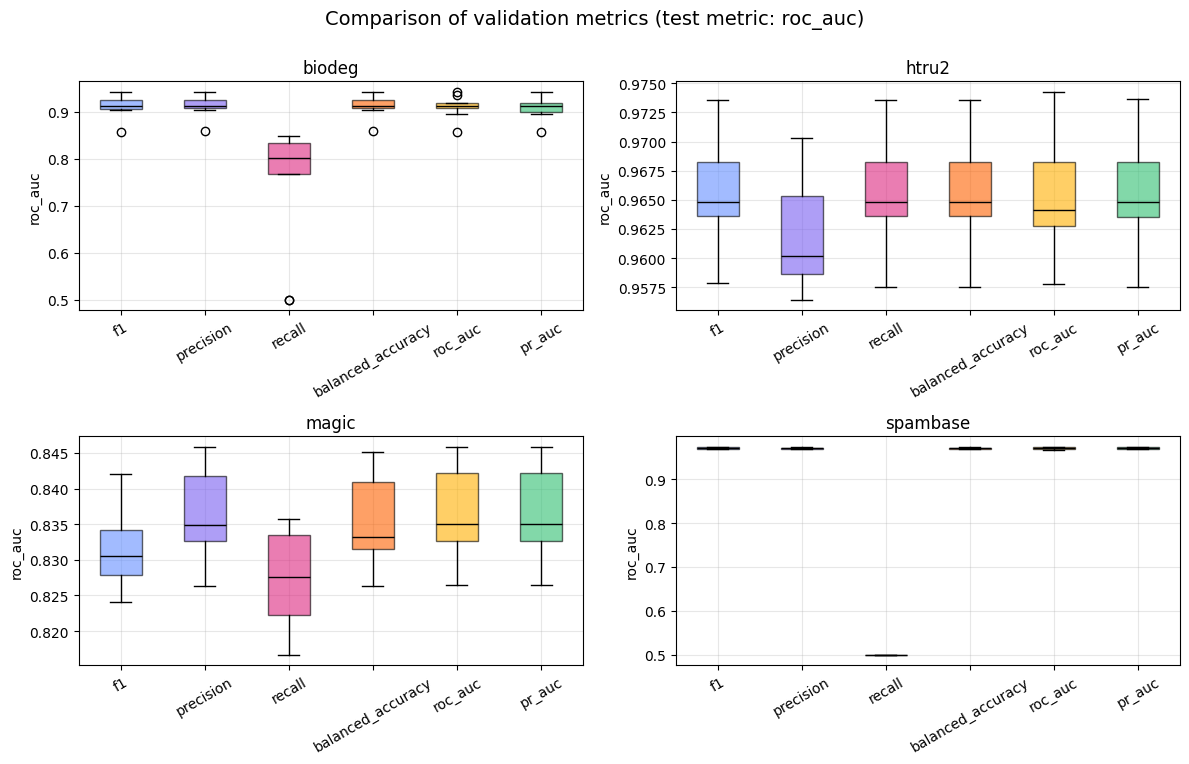

In [36]:
plot_boxplot(df, measures=("f1", "precision", "recall", "balanced_accuracy", "roc_auc", "pr_auc"),
             test_metric="roc_auc")

In [ ]:
df_f1 = compare_validation_strategies(
    processed_datasets,
    measures=("f1", "precision", "recall", "balanced_accuracy", "roc_auc", "pr_auc"),
    lambda_values=np.logspace(-4, 2, 50),
    n_repeats=10,
    test_metric="f1",
    max_iter=200,
    random_state=42
)

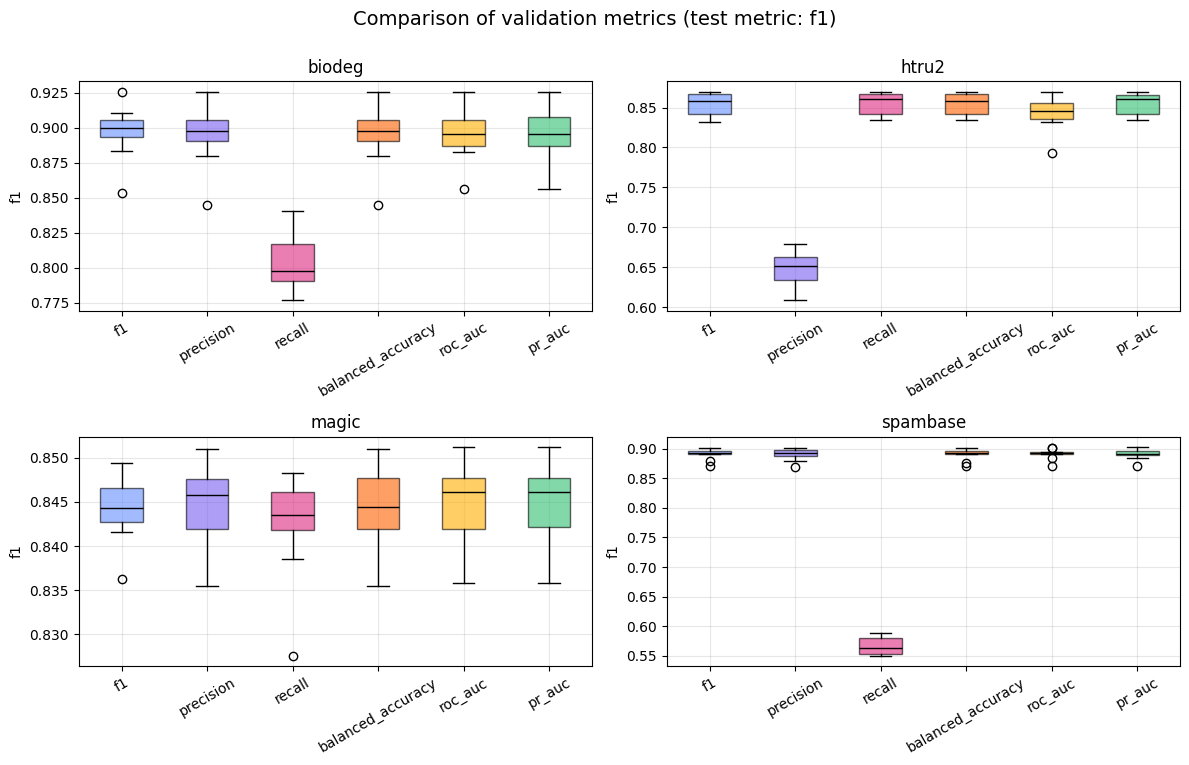

In [ ]:
plot_boxplot(df_f1, measures=("f1", "precision", "recall", "balanced_accuracy", "roc_auc", "pr_auc"),
             test_metric="f1")